In [1]:
import sys
import subprocess
import importlib.util
# Check if symfit is already installed
if importlib.util.find_spec("symfit") is None:
    print("Installing symfit...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "symfit"])
    print("SymFit installed successfully!")
else:
    print("SymFit is already installed.")

# Import symfit and verify installation
import symfit
print(f"SymFit version: {symfit.__version__}")

import pandas as pd
import numpy as np
from symfit import parameters,variables,Fit,D,ODEModel
import matplotlib.pyplot as plt

dtt = pd.read_csv('1p4mM-CP1_100-eq-DTT.csv', \
                  sep=';')
dtt.head()

SymFit is already installed.
SymFit version: 0.5.6


,average time,time,linear area,1-arm area,cyclic area,1-arm-MAD-DTT area,sum,linear-frac,arm-frac,cyclic-frac,armMADDTT-frac,linear,arm,cyclic,armMADDTT,M CPL3
0,0:02:54,2.900000,6970000.0,2.740000e+09,2.070000e+09,4.370000e+08,5.250000e+09,0.00133,0.5210,0.394,0.0832,0.000002,0.000733,0.000554,0.000117,0.001406
1,0:13:49,13.816667,67800000.0,1.460000e+09,2.230000e+09,1.020000e+09,4.780000e+09,0.01420,0.3060,0.467,0.2130,0.000020,0.000431,0.000656,0.000300,NaN
2,0:32:25,32.416667,213000000.0,5.690000e+08,1.130000e+09,1.480000e+09,3.390000e+09,0.06280,0.1680,0.333,0.4370,0.000088,0.000236,0.000468,0.000614,NaN
3,0:47:14,47.233333,357000000.0,3.190000e+08,6.150000e+08,1.590000e+09,2.880000e+09,0.12400,0.1110,0.214,0.5520,0.000174,0.000156,0.000300,0.000776,NaN
4,1:01:14,61.233333,521000000.0,2.110000e+08,6.540000e+08,1.610000e+09,2.990000e+09,0.17400,0.0704,0.219,0.5370,0.000245,0.000099,0.000307,0.000755,NaN


Derivative(a, t; k2) = 0.0072*e
Derivative(ab, t; k2) = -k2*ab - 0.037*ab
Derivative(d, t; k2) = k2*ab - 0.00705*d
Derivative(e, t; k2) = 0.037*ab + 0.00705*d - 0.0072*e

Parameter Value        Standard Deviation
k2        9.513336e-04 1.932397e-03
Status message         Optimization terminated successfully.
Number of iterations   3
Objective              <symfit.core.objectives.LeastSquares object at 0x169ecb4d0>
Minimizer              <symfit.core.minimizers.BFGS object at 0x169ecb620>

Goodness of fit qualifiers:
chi_squared            2.9340241614996157e-07
objective_value        1.4670120807498078e-07
r_squared              0.9620752527175354


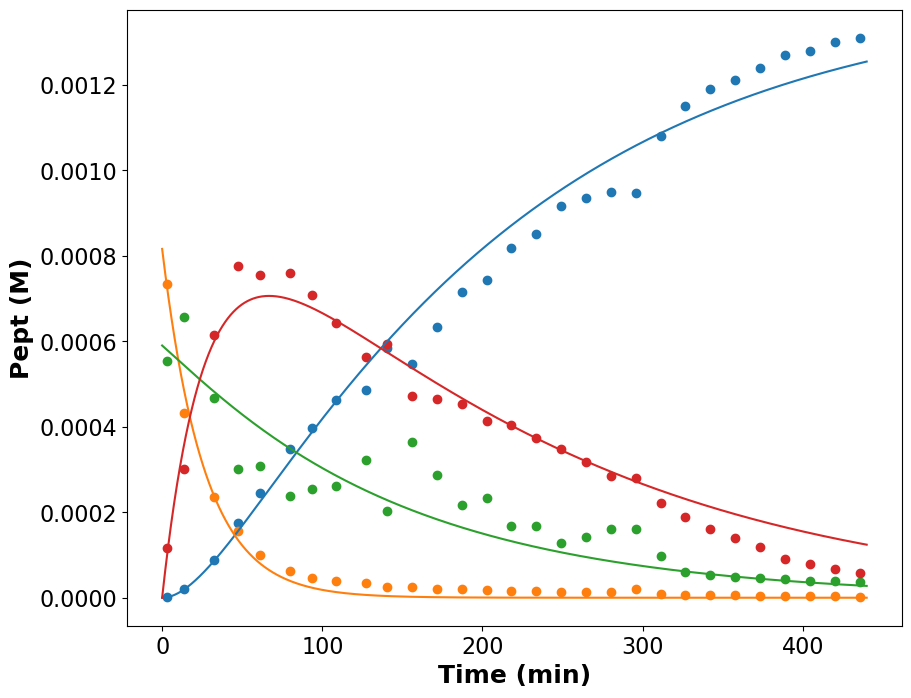

In [2]:


%matplotlib nbagg
%matplotlib inline 

# If you're using symfit or another package that depends on numpy.product
# You might need to add this compatibility function
if not hasattr(np, 'product'):
    np.product = np.prod  # Create an alias for the correct function

a, ab, d, e, t = variables('a, ab, d, e, t')
k2, k3, k3a, k4 = parameters('k2, k3, k3a, k4')
#k2 = 0.003
k3 = 0.00705
k3a = 0.037
k4 = 0.0072

t_data=np.array(dtt.time, dtype=np.float64)
a_data=np.array(dtt.linear, dtype=np.float64)
ab_data=np.array(dtt.arm, dtype=np.float64)
d_data=np.array(dtt.cyclic, dtype=np.float64)
e_data=np.array(dtt.armMADDTT, dtype=np.float64)

#t0=dtt.iat[0,1]
t0=0.0
#a0 = dtt.iat[0,11]
a0= 0.0
#ab0 = dtt.iat[0,12]
ab0 =0.000816
#d0 = dtt.iat[0,13]
d0 = 0.000590
#e0= dtt.iat[0,14]
e0=0.0


model_dict = {D(a, t): k4*e, \
              D(ab, t): -k3a*ab - k2*ab, \
              D(d, t): -k3*d + k2*ab, \
              D(e, t): k3a*ab + k3*d - k4*e}


ode_model = ODEModel(model_dict, initial={t: t0, a: a0, ab: ab0, d: d0, e: e0})
print (ode_model)
fit = Fit(ode_model, t=t_data, a=a_data, ab=ab_data, d=d_data, e=e_data)
fit_result = fit.execute()
print (fit_result)

tvec = np.linspace(0, 440, 100000)
a, ab, d, e = ode_model(t=tvec, **fit_result.params)

plt.figure(figsize=(10, 8))
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.plot(tvec, a, label='Linear_fit')
plt.plot(tvec, ab, label='Linear-MAD_fit')
plt.plot(tvec, d, label='Cyclic_fit')
plt.plot(tvec, e, label='linear-MAD-DTT_fit')
#plt.plot(tvec, f, label='DTT_fit')
plt.scatter(t_data, a_data, label='Linear')
plt.scatter(t_data, ab_data, label='linear-MAD')
plt.scatter(t_data, d_data, label='Cyclic')
plt.scatter(t_data, e_data, label='linear-MAD-DTT')
#plt.ylim(-0.0001,0.001)
plt.xlabel('Time (min)', fontsize=18, fontweight = 'bold')
plt.ylabel('Pept (M)', fontsize=18, fontweight = 'bold')
#plt.legend(loc='best')

plt.show()

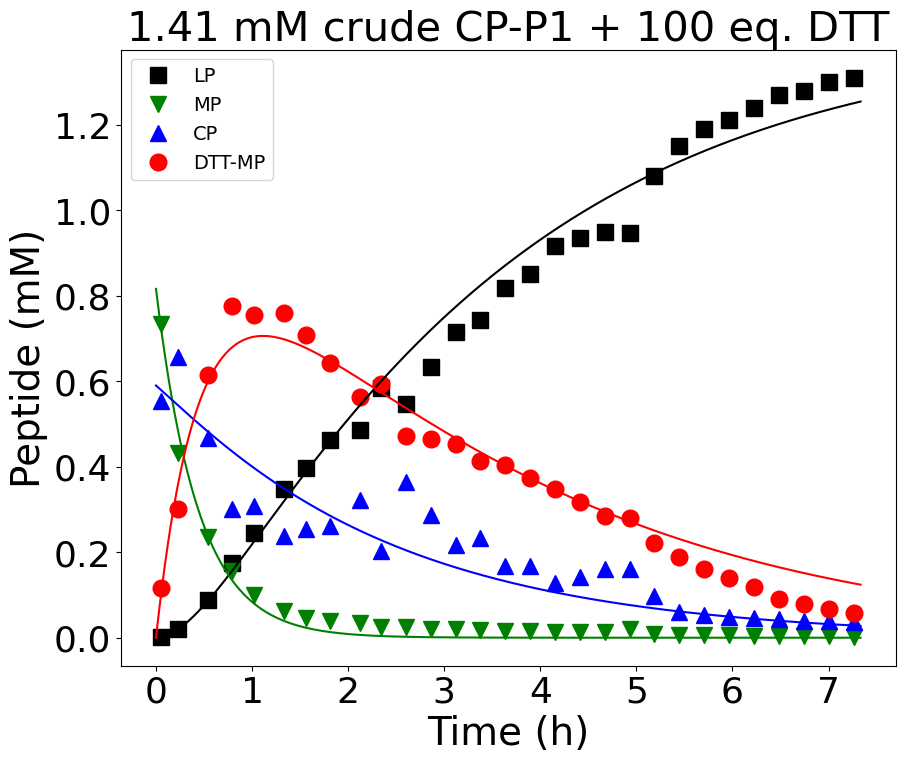

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1, figsize=(10,8))

ax.plot(t_data/60, a_data*1000, marker='s', markersize=12, ls='', color='black', label='LP')
ax.plot(t_data/60, ab_data*1000, marker='v', ls='', markersize=12, color='green', label='MP')
ax.plot(t_data/60, d_data*1000, marker='^', markersize=12, ls='', color='blue', label='CP')
ax.plot(t_data/60, e_data*1000, marker='o', markersize=12, ls='', color='red', label='DTT-MP')
ax.plot(tvec/60, a*1000, 'black', tvec/60, ab*1000, 'green', tvec/60, d*1000, 'blue', tvec/60, e*1000, 'red')

#ax.set_ylim(bottom=-0.000065, top=0.001375)
#ax.patch.set_facecolor(color='b')
#ax.patch.set_alpha(0)

ax.set_xlabel('Time (h)', fontsize=28, fontweight = 'normal')
ax.set_ylabel('Peptide (mM)', fontsize=28, fontweight = 'normal')
plt.xticks(fontsize=26, fontweight = 'normal')
plt.yticks(fontsize=26, fontweight = 'normal')
ax.set_title('1.41 mM crude CP-P1 + 100 eq. DTT', fontsize=30, fontweight = 'normal')
ax.legend(loc=0,fontsize=14)

#from matplotlib import ticker
#formatter = ticker.ScalarFormatter(useMathText=True)
#formatter.set_scientific(True) 
#formatter.set_powerlimits((-1,1)) 
#ax.yaxis.set_major_formatter(formatter)

plt.show()
fig.savefig('1p4mMP1-100eqDTT-1.svg', dpi=300, transparent=True)

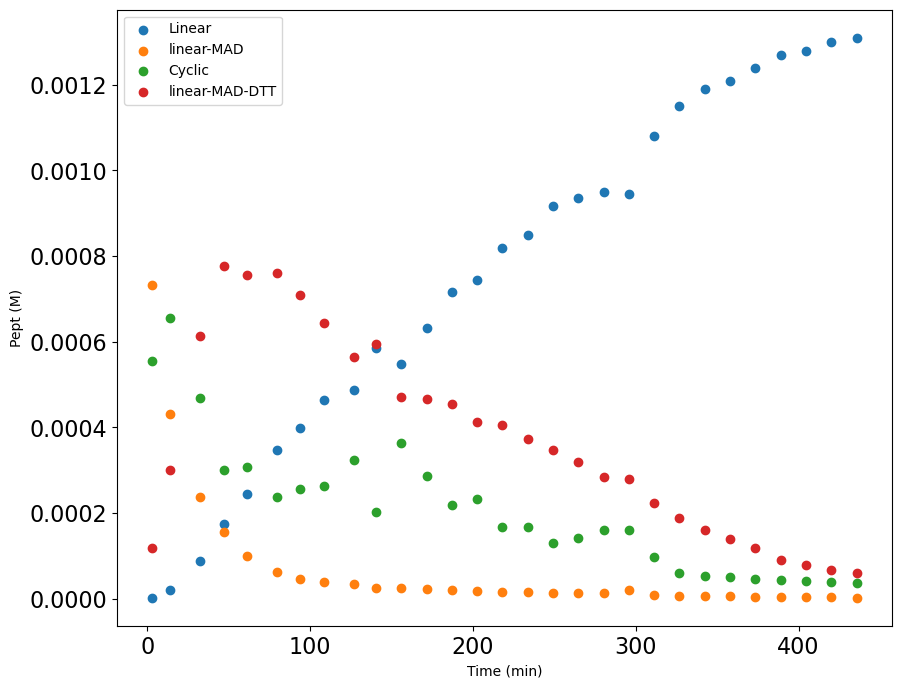

In [4]:
plt.figure(figsize=(10, 8))
plt.scatter(t_data, a_data, label='Linear')
plt.scatter(t_data, ab_data, label='linear-MAD')
plt.scatter(t_data, d_data, label='Cyclic')
plt.scatter(t_data, e_data, label='linear-MAD-DTT')
plt.xlabel('Time (min)')
plt.ylabel('Pept (M)')
plt.legend(loc='best')
plt.show()

Derivative(a, t; k1, k2, k3, k3a, k4) = k4*e
Derivative(ab, t; k1, k2, k3, k3a, k4) = k2*e1 - k3a*ab*g
Derivative(abc, t; k1, k2, k3, k3a, k4) = -k1*abc*g
Derivative(d, t; k1, k2, k3, k3a, k4) = -k3*d*g
Derivative(e, t; k1, k2, k3, k3a, k4) = k3*d*g + k3a*ab*g - k4*e
Derivative(e1, t; k1, k2, k3, k3a, k4) = k1*abc*g - k2*e1
Derivative(g, t; k1, k2, k3, k3a, k4) = -k1*abc*g - k3*d*g - k3a*ab*g

Parameter Value        Standard Deviation
k1        5.000000e+01 9.833013e+04
k2        6.000000e+01 1.140525e+05
k3        4.361247e-02 4.046167e-03
k3a       2.696351e-01 6.906232e-02
k4        7.227079e-03 3.468123e-04
Status message         Optimization terminated successfully.
Number of iterations   44
Objective              <symfit.core.objectives.LeastSquares object at 0x16a1c4e10>
Minimizer              <symfit.core.minimizers.BFGS object at 0x16a1c4f50>

Goodness of fit qualifiers:
chi_squared            2.7623869224988495e-07
objective_value        1.3811934612494247e-07
r_squared      

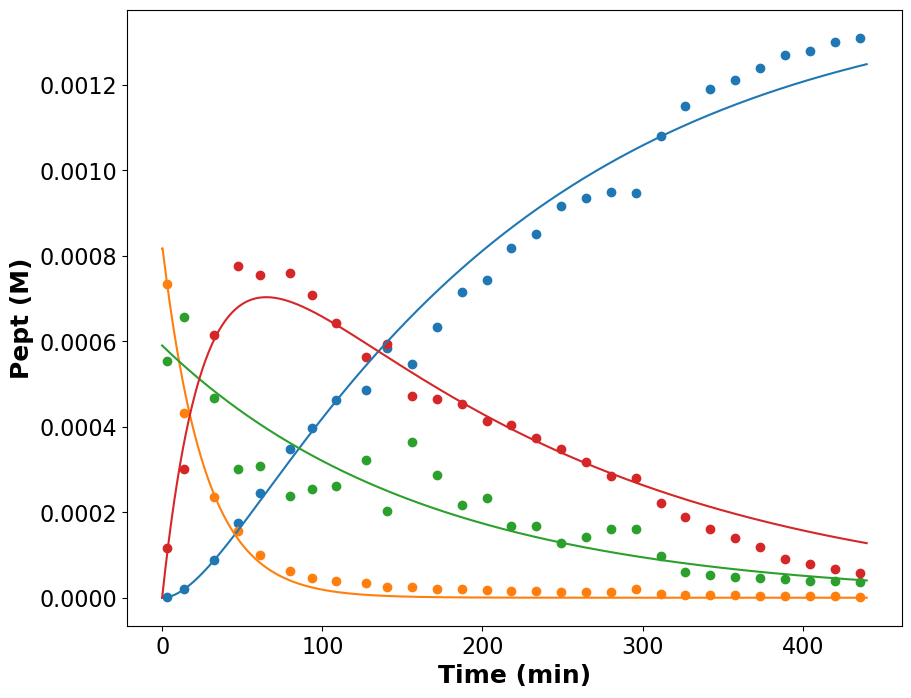

In [5]:
# With 2-arm-MAD included and k2 removed

import numpy as np
from symfit import parameters,variables,Fit,D,ODEModel, Parameter
import matplotlib.pyplot as plt

%matplotlib nbagg
%matplotlib inline 

# a=linear, ab=pept-mad, abc=mad-pept-mad, d=cyclic, e=pept-mad-dtt, e1=mad-pept-mad-dtt

a, ab, abc, d, e, e1, g, t = variables('a, ab, abc, d, e, e1, g, t')
k1, k2, k3, k3a, k4 = parameters('k1, k2, k3, k3a, k4')
k1 = Parameter('k1', value=50) # min=1*60, max=2*60 
k2 = Parameter('k2', value=60) #, min=0.009*60, max=0.045*60)
k3 = Parameter('k3', value=0.007) #, min=0.3*60, max=0.8*60)
k3a = Parameter('k3a', value=0.037) #, min=0.3*60, max=0.8*60)
k4 = Parameter('k4', value=0.0072) #, min=0.3*60, max=0.8*60)

#k2=50
#k1=68
#k3 = 0.0063
#k3a = 0.037
#k4 = 0.0072

t_data=np.array(dtt.time, dtype=np.float64)
a_data=np.array(dtt.linear, dtype=np.float64)
ab_data=np.array(dtt.arm, dtype=np.float64)
d_data=np.array(dtt.cyclic, dtype=np.float64)
e_data=np.array(dtt.armMADDTT, dtype=np.float64)

#t0=dtt.iat[0,1]
t0=0.0
#a0 = dtt.iat[0,11]
a0= 0.0
#ab0 = dtt.iat[0,12]
ab0 =0.000816
#d0 = dtt.iat[0,13]
d0 = 0.000590
#e0= dtt.iat[0,14]
e0=0.0
abc0 = 0.00001
e10 = 0.0
g0 = 0.141



model_dict = {D(a, t): k4*e, \
              D(ab, t): -k3a*ab*g + k2*e1, \
              D(d, t): -k3*d*g, \
              D(e, t): k3a*ab*g + k3*d*g - k4*e, \
              D(e1, t): k1*abc*g - k2*e1, \
              D(abc, t): -k1*abc*g, \
              D(g, t): -k1*abc*g - k3*d*g - k3a*ab*g}


ode_model = ODEModel(model_dict, initial={t: t0, a: a0, ab: ab0, abc: abc0, d: d0, e: e0, e1:e10, g:g0})
print (ode_model)
fit = Fit(ode_model, t=t_data, a=a_data, ab=ab_data, abc=None, d=d_data, e=e_data, e1=None, g=None)
fit_result = fit.execute()
print (fit_result)

tvec = np.linspace(0, 440, 100000)
a, ab, abc, d, e, e1, g = ode_model(t=tvec, **fit_result.params)

plt.figure(figsize=(10, 8))
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.plot(tvec, a, label='Linear_fit')
plt.plot(tvec, ab, label='Linear-MAD_fit')
plt.plot(tvec, d, label='Cyclic_fit')
plt.plot(tvec, e, label='linear-MAD-DTT_fit')
#plt.plot(tvec, f, label='DTT_fit')
plt.scatter(t_data, a_data, label='Linear')
plt.scatter(t_data, ab_data, label='linear-MAD')
plt.scatter(t_data, d_data, label='Cyclic')
plt.scatter(t_data, e_data, label='linear-MAD-DTT')
#plt.ylim(-0.0001,0.001)
plt.xlabel('Time (min)', fontsize=18, fontweight = 'bold')
plt.ylabel('Pept (M)', fontsize=18, fontweight = 'bold')
#plt.legend(loc='best')

plt.show()